### Import Packages

In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from scipy import stats

import tensorflow as tf
from keras.models import Model, load_model
from keras.layers import Input, LSTM, Dense, MultiHeadAttention, GlobalAveragePooling1D, Masking
from keras.optimizers import Adam
from keras.saving import register_keras_serializable

seed = 42
os.environ['PYTHONHASHSEED'] = str(seed)
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

print("TensorFlow version: ", tf.__version__)
print("Number of GPUs available: ", len(tf.config.list_physical_devices('GPU')))

wind_MLP = load_model('wind_MLP.keras')

TensorFlow version:  2.19.0
Number of GPUs available:  1


### Data Preprocessing

In [4]:
cols = ['u','u_e','u_n']
scaled_cols = ['scaled_' + col for col in cols]

# Load datasets
df_buoy = pd.read_csv('WLIS_data.csv')
df_buoy = df_buoy.rename(columns={'WSPD':'u'})
df_buoy['TmStamp'] = pd.to_datetime(df_buoy['TmStamp'], format='mixed')
df_buoy.set_index('TmStamp', inplace=True)

df_stn = pd.read_csv('Sikorsky_data.csv')
df_stn = df_stn.rename(columns={'WSPD':'u'})
df_stn['TmStamp'] = pd.to_datetime(df_stn['TmStamp'], format='mixed')
df_stn.set_index('TmStamp', inplace=True)

# Add east and north components
alpha = -13
df_buoy['rad'] = np.pi/180 * ((alpha + 630 - df_buoy['WDIR']) % 360)
df_buoy['u_e'] = df_buoy['u'] * np.cos(df_buoy['rad'])
df_buoy['u_n'] = df_buoy['u'] * np.sin(df_buoy['rad'])

df_stn['rad'] = np.pi/180 * ((alpha + 630 - df_stn['WDIR']) % 360)
df_stn['u_e'] = df_stn['u'] * np.cos(df_stn['rad'])
df_stn['u_n'] = df_stn['u'] * np.sin(df_stn['rad'])

# Transform station wind into buoy wind
def wind_transform(df_stn):
    wind_T_uc = wind_MLP.predict(df_stn[cols[1:]], verbose=0)
    u_e, u_n = wind_T_uc[:, 0], wind_T_uc[:, 1]
    wind_T_u = np.sqrt(u_e**2 + u_n**2)
    return pd.DataFrame({'u': wind_T_u, 'u_e': u_e, 'u_n': u_n}, index=df_stn.index)

df_T = wind_transform(df_stn)

# df_test: [2024-07-01 00:00:00 ~ 2025-06-30 23:00:00]
split = pd.to_datetime('2024-06-30 23:59:00')
df_buoy_train = df_buoy[df_buoy.index < split]
df_buoy_test = df_buoy[df_buoy.index > split]
df_stn_train = df_stn[df_stn.index < split]
df_stn_test = df_stn[df_stn.index > split]
df_T_train = df_T[df_T.index < split]
df_T_test = df_T[df_T.index > split]

# Data normalization
scaled_wave, scaled_wind, scaled_T = MinMaxScaler(), MinMaxScaler(), MinMaxScaler()

df_buoy_train, df_buoy_test = df_buoy_train.copy(), df_buoy_test.copy()
df_buoy_train.loc[:, 'scaled_H'] = scaled_wave.fit_transform(df_buoy_train[['H']])
df_buoy_test.loc[:, 'scaled_H'] = scaled_wave.transform(df_buoy_test[['H']])
df_buoy_train.loc[:, scaled_cols] = scaled_wind.fit_transform(df_buoy_train[cols])
df_buoy_test.loc[:, scaled_cols] = scaled_wind.transform(df_buoy_test[cols])

df_T_train, df_T_test = df_T_train.copy(), df_T_test.copy()
df_T_train.loc[:, scaled_cols] = scaled_T.fit_transform(df_T_train[cols])
df_T_test.loc[:, scaled_cols] = scaled_T.transform(df_T_test[cols])

### Data Preparation: Train-Test-Validation Split

In [5]:
step, output = 24, 12
features = ['scaled_H'] + scaled_cols

def create_sequences(df_buoy, df_T, step, output):
    X, y = [], []
    periods = step + output
    for i in range(len(df_buoy) - periods + 1):
        window = df_buoy.iloc[i:(i+periods)]
        expect = pd.date_range(start=window.index[0], periods=periods, freq='h')
        if not window.index.equals(expect):
            continue
        X_seq = window.values.copy()
        X_seq[step:, 0] = -1
        X_seq[step:, 1:] = df_T.iloc[(i+step):(i+periods)].values
        X.append(X_seq)
        y.append(window.iloc[step:, 0].values)
    return np.array(X), np.array(y)

# Validation set: [2007-11-01 00:00:00 ~ 2008-10-31 23:00:00]
split1 = pd.to_datetime('2007-10-31 23:59:00')
split2 = pd.to_datetime('2008-10-31 23:59:00')
df_buoy_val = df_buoy_train[(df_buoy_train.index > split1) & (df_buoy_train.index < split2)]
df_buoy_train = df_buoy_train[(df_buoy_train.index < split1) | (df_buoy_train.index > split2)]
df_stn_val = df_stn_train[(df_stn_train.index > split1) & (df_stn_train.index < split2)]
df_stn_train = df_stn_train[(df_stn_train.index < split1) | (df_stn_train.index > split2)]
df_T_val = df_T_train[(df_T_train.index > split1) & (df_T_train.index < split2)]
df_T_train = df_T_train[(df_T_train.index < split1) | (df_T_train.index > split2)]

X_val, y_val = create_sequences(df_buoy_val[features], df_T_val[scaled_cols], step, output)
X_test, y_test = create_sequences(df_buoy_test[features], df_T_test[scaled_cols], step, output)

print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(8749, 36, 4) (8749, 12)
(8725, 36, 4) (8725, 12)


### Model Selection and Implementation

In [6]:
rho = 0.054

# Add future wind noise
def add_noise(df, abs_std, rel_std, random_seed=42):
    rng = np.random.default_rng(random_seed)
    wind = df[cols].to_numpy(dtype=float)
    stds = abs_std + rel_std * wind[:, 0]
    cov = np.array([[1, rho], [rho, 1]])
    L_cov = np.linalg.cholesky(cov)
    z = rng.normal(0, 1, size=(wind.shape[0], 2))
    noise = z @ L_cov.T * stds[:, None]
    nu_e = wind[:, 1] + noise[:, 0]
    nu_n = wind[:, 2] + noise[:, 1]
    nu = np.linalg.norm(np.column_stack([nu_e, nu_n]), axis=1)
    nu = np.maximum(nu, 0.25)
    return pd.DataFrame({'u':nu, 'u_e':nu_e, 'u_n':nu_n}, index=df.index)

# Gaussian NLL loss
@register_keras_serializable()
def gaussian_nll_loss(y_true, y_pred):
    y_true = tf.reshape(y_true, [tf.shape(y_true)[0], -1])
    mean, log_var = tf.split(y_pred, 2, axis=1)
    log_var = tf.clip_by_value(log_var, -10.0, 10.0)
    loss = 0.5 * (log_var + tf.square(y_true-mean) / tf.exp(log_var))
    return tf.reduce_mean(loss)

In [ ]:
# Model architecture
def create_model(X):
    # Input layer with shape: (batch_size, time_steps, features)
    input_layer = Input(shape=(X.shape[1], X.shape[2]))

    # Masking layer
    mask_layer = Masking(-1)(input_layer)

    # LSTM layer
    units = 16
    lstm_1 = LSTM(units=256, activation='tanh', return_sequences=True)(mask_layer)
    lstm_2 = LSTM(units=16, activation='tanh', return_sequences=True)(lstm_1)
    lstm_3 = LSTM(units=64, activation='tanh', return_sequences=True)(lstm_2)
    lstm_out = LSTM(units=units, activation='tanh', return_sequences=True)(lstm_3)
    
    # Attention layer
    num_heads = 2
    attn_layer = MultiHeadAttention(num_heads=num_heads, key_dim=units//num_heads)
    attn_out, attn_scores = attn_layer(lstm_out, lstm_out, return_attention_scores=True)
    
    # Pooling layer
    pooled_out = GlobalAveragePooling1D()(attn_out)

    # Output layer
    output_layer = Dense(12 * 2)(pooled_out)
    
    # Build model
    model = Model(inputs=input_layer, outputs=output_layer)
    model.compile(optimizer=Adam(learning_rate=1e-4), loss=gaussian_nll_loss)
    attn_model = Model(inputs=input_layer, outputs=attn_scores)
    
    return model, attn_model

In [ ]:
epochs = 100
samples = 20
batch_size = 64
model_file = 'model_aug_CI.keras'

# Train and save the model
model, attn_model = create_model(X_test)
loss, val_loss = [], []
best_val_loss, count = np.inf, 0

for i in range(epochs):
    epoch_loss, epoch_val_loss = [], []

    for n in range(samples):
        rng_epoch = np.random.default_rng(100*(i+1)+n)
        abs_std = rng_epoch.uniform(0, 1.5)
        rel_std = rng_epoch.uniform(0, 0.5)
        
        # Add wind noise
        df_stn_train_nu = add_noise(df_stn_train[cols], abs_std, rel_std, random_seed=100*(i+1)+n)
        df_stn_train_nu_T = wind_transform(df_stn_train_nu)
        df_stn_train_nu_T.loc[:, scaled_cols] = scaled_T.transform(df_stn_train_nu_T[cols])
        X_train, y_train = create_sequences(df_buoy_train[features], df_stn_train_nu_T[scaled_cols], step, output)
        
        history = model.fit(X_train, y_train, epochs=1, batch_size=batch_size, validation_data=(X_val, y_val), verbose=0)
        epoch_loss.append(history.history['loss'][0])
        epoch_val_loss.append(history.history['val_loss'][0])
    
    loss.append(np.mean(epoch_loss))
    val_loss.append(np.mean(epoch_val_loss))
    print(f'Epoch {i+1}: loss={np.mean(epoch_loss):.4f}, val_loss={np.mean(epoch_val_loss):.4f}')

    # Early stopping
    if val_loss[-1] < best_val_loss:
        best_val_loss = val_loss[-1]
        model.save(model_file)
        count = 0
    else:
        count += 1
        if count >= 10:
            break

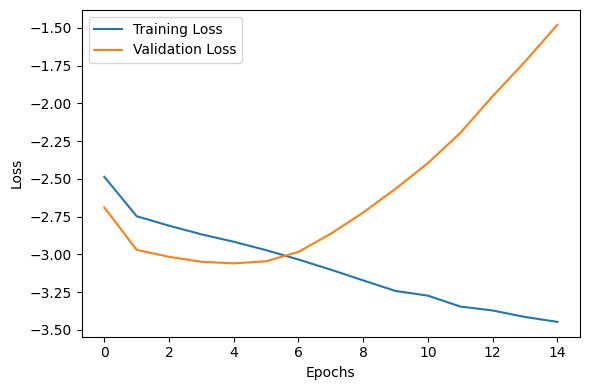

In [7]:
df = pd.read_csv('loss_2.csv')
loss = df['loss']
val_loss = df['val_loss']

# Plot the training & validation loss over epochs
plt.figure(figsize=(6, 4))
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
head_idx = 0
attn_weights = attn_model.predict(X_test, verbose=0)
attn_head_matrix = attn_weights[:, head_idx, :, :]
attn_matrix = np.mean(attn_head_matrix, axis=0)

plt.figure(figsize=(6, 5))
sns.heatmap(attn_matrix, cmap='viridis')
plt.xlabel('Key Time Steps')
plt.ylabel('Query Time Steps')
plt.tight_layout()
plt.show()

### Model Evaluation

In [7]:
model_aug_CI = load_model('model_aug_CI.keras')
y_true = scaled_wave.inverse_transform(y_test)

# Load dataset
df_fcst = pd.read_csv('Sikorsky_fcst.csv')
df_fcst = df_fcst.rename(columns={'WSPD':'u'})
df_fcst['TmStamp'] = pd.to_datetime(df_fcst['TmStamp'], format='mixed')
df_fcst.set_index('TmStamp', inplace=True)

# Wind transform & Data normalization
df_fcst_T = wind_transform(df_fcst)
df_fcst_T.loc[:, scaled_cols] = scaled_T.transform(df_fcst_T[cols])

# Model predictions (mean + 95% CI)
X_fcst = create_sequences(df_buoy_test[features], df_fcst_T[scaled_cols], step, output)[0]
y_pred = model_aug_CI.predict(X_fcst, verbose=0)
mean_pred, log_var_pred = tf.split(y_pred, 2, axis=1)
sigma_pred = np.sqrt(tf.exp(log_var_pred))
lower_pred = mean_pred - 1.96 * sigma_pred
upper_pred = mean_pred + 1.96 * sigma_pred
mean_pred_raw  = scaled_wave.inverse_transform(mean_pred)
lower_pred_raw = scaled_wave.inverse_transform(lower_pred)
upper_pred_raw = scaled_wave.inverse_transform(upper_pred)

# Exceedances
exceed = (y_true < lower_pred_raw) | (y_true > upper_pred_raw)
print(f'Total number of samples: {y_true.shape[0]}')
print('Exceedance per output:', ', '.join([f'{i:d}' for i in np.sum(exceed, axis=0)]))

# RMSE
rmse_mean = np.sqrt(mean_squared_error(y_true, mean_pred_raw))
rmse_arr_mean = np.sqrt(mean_squared_error(y_true, mean_pred_raw, multioutput='raw_values'))
rmse_arr_lower = np.sqrt(mean_squared_error(y_true, lower_pred_raw, multioutput='raw_values'))
rmse_arr_upper = np.sqrt(mean_squared_error(y_true, upper_pred_raw, multioutput='raw_values'))
print(f'Test RMSE (mean): {rmse_mean:.3f}')
print('Test RMSE (mean_pred) per output:', ', '.join([f'{rmse:.3f}' for rmse in rmse_arr_mean]))
print('Test RMSE (lower_pred) per output:', ', '.join([f'{rmse:.3f}' for rmse in rmse_arr_lower]))
print('Test RMSE (upper_pred) per output:', ', '.join([f'{rmse:.3f}' for rmse in rmse_arr_upper]))

Total number of samples: 8725
Exceedance per output: 261, 454, 610, 685, 868, 931, 975, 1007, 940, 906, 831, 824
Test RMSE (mean): 0.404
Test RMSE (mean_pred) per output: 0.209, 0.279, 0.336, 0.380, 0.412, 0.432, 0.441, 0.445, 0.445, 0.460, 0.451, 0.465
Test RMSE (lower_pred) per output: 0.470, 0.594, 0.664, 0.697, 0.730, 0.748, 0.779, 0.800, 0.824, 0.820, 0.866, 0.922
Test RMSE (upper_pred) per output: 0.583, 0.668, 0.755, 0.825, 0.859, 0.892, 0.900, 0.902, 0.907, 0.945, 0.942, 0.949


In [8]:
# RMSE + 95% CI
N_samples = 1000
rmse_samples = np.zeros((N_samples, y_true.shape[1]))

for i in range(N_samples):
    rng = np.random.default_rng(i)
    y_sample = rng.normal(loc=mean_pred, scale=sigma_pred)
    y_sample_raw = scaled_wave.inverse_transform(y_sample)
    rmse_samples[i, :] = np.sqrt(mean_squared_error(y_true, y_sample_raw, multioutput='raw_values'))

print('Test RMSE (mean CI) per output:', ', '.join([f'{rmse:.3f}' for rmse in np.percentile(rmse_samples, 50, axis=0)]))
print('Test RMSE (lower CI) per output:', ', '.join([f'{rmse:.3f}' for rmse in np.percentile(rmse_samples, 2.5, axis=0)]))
print('Test RMSE (upper CI) per output:', ', '.join([f'{rmse:.3f}' for rmse in np.percentile(rmse_samples, 97.5, axis=0)]))

Test RMSE (mean CI) per output: 0.325, 0.402, 0.464, 0.508, 0.540, 0.560, 0.573, 0.580, 0.585, 0.600, 0.603, 0.623
Test RMSE (lower CI) per output: 0.319, 0.395, 0.456, 0.500, 0.531, 0.551, 0.562, 0.571, 0.575, 0.590, 0.593, 0.612
Test RMSE (upper CI) per output: 0.330, 0.408, 0.471, 0.517, 0.549, 0.569, 0.583, 0.590, 0.595, 0.611, 0.614, 0.634


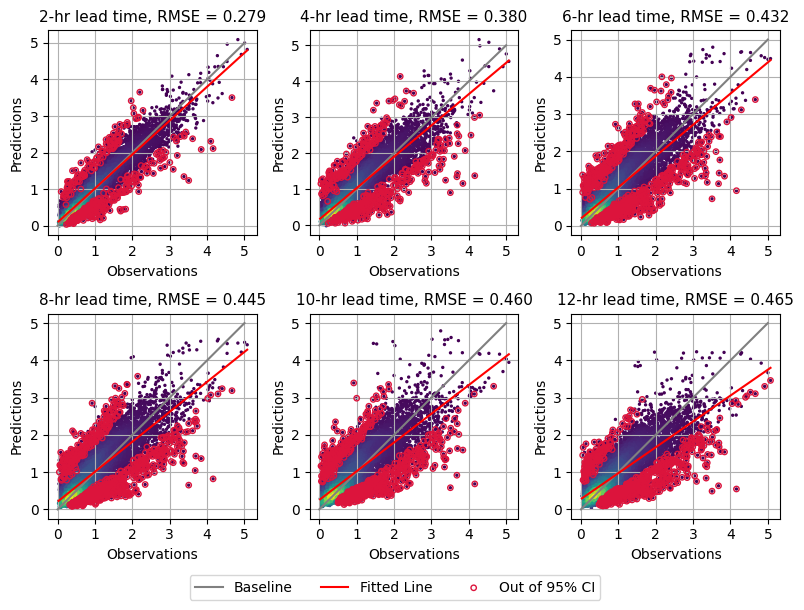

In [9]:
def pred_vs_obs(y_true, y_pred, rmse_array, exceed):
    fig, axes = plt.subplots(2, 3, figsize=(8, 6))
    axes = axes.flatten()
    baseline, = plt.plot([], [], color='grey', label='Baseline')
    fit_line, = plt.plot([], [], color='r', label='Fitted Line')

    for i in range(1, 12, 2):
        ax = axes[i//2]
        yt, yp = y_true[:,i], y_pred[:,i].flatten()
        
        ax.plot([0, 5], [0, 5], color='grey')
        ax.plot(np.unique(yt), np.poly1d(np.polyfit(yt, yp, 1))(np.unique(yt)), color='r')
        kernel = stats.gaussian_kde(np.vstack([yt, yp]))(np.vstack([yt, yp]))
        ax.scatter(yt, yp, c=kernel, s=2, cmap='viridis')
        scatter = ax.scatter(yt[exceed[:,i]], yp[exceed[:,i]], facecolors='none', edgecolors='crimson', s=15, label='Out of 95% CI', zorder=10)

        ax.set_title(f'{i+1}-hr lead time, RMSE = {rmse_array[i]:.3f}', fontsize=11)
        ax.set_xticks([0, 1, 2, 3, 4, 5])
        ax.set(xlabel='Observations', ylabel='Predictions')
        ax.grid(True)

    fig.legend(handles=[baseline, fit_line, scatter], loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.02))
    plt.tight_layout(rect=[0, 0.03, 1, 1])
    # plt.savefig('exp_3_1.png', dpi=1200, format='png')
    plt.show()

pred_vs_obs(y_true, mean_pred_raw, rmse_arr_mean, exceed)

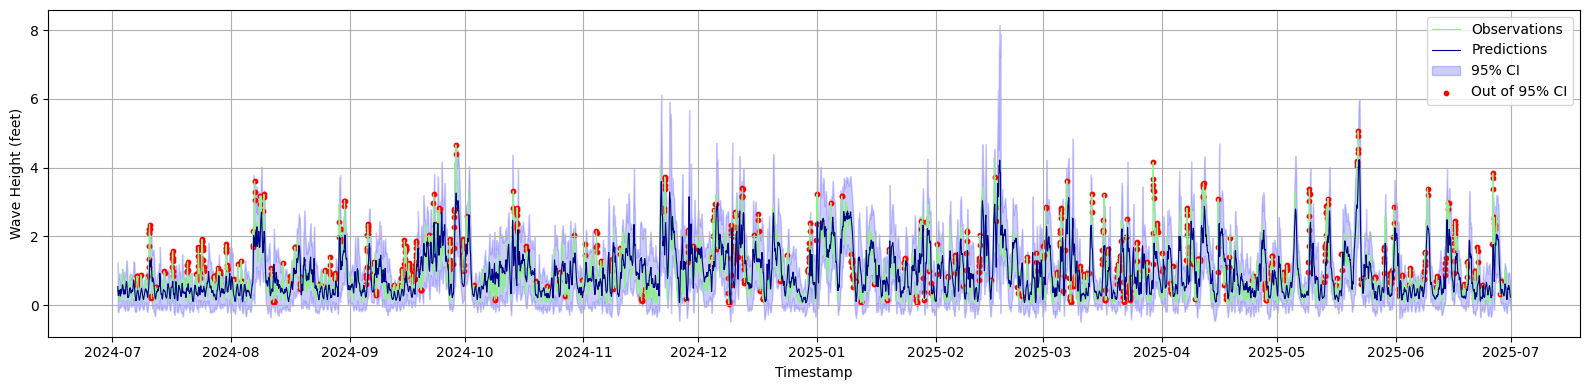

In [10]:
idx = 11
start = step + idx
end = len(df_buoy_test) - (output - idx - 1)

time_idx = df_buoy_test.index[start:end]
y_obs = y_true[:, idx]
y_lower = lower_pred_raw[:, idx]
y_upper = upper_pred_raw[:, idx]
mask = (y_obs < y_lower) | (y_obs > y_upper)

plt.figure(figsize=(16, 4))
plt.plot(time_idx, y_obs, linewidth=0.8, color='lightgreen', label='Observations')
plt.plot(time_idx, mean_pred_raw[:, idx], linewidth=0.8, color='darkblue', label='Predictions')
plt.fill_between(time_idx, y_lower, y_upper, color='b', alpha=0.2, label='95% CI')
plt.scatter(time_idx[mask], y_obs[mask], color='r', s=10, label='Out of 95% CI')

plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xlabel('Timestamp')
plt.ylabel('Wave Height (feet)')
plt.grid(True)
plt.legend()
plt.tight_layout()
# plt.savefig('exp_3_2.png', dpi=1200, format='png')
plt.show()